In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib as mpl
import random

In [2]:
def incidence_matrix(edges, nodes):

    num_edges = len(edges)
    num_nodes = len(nodes)
    
    node_to_idx = {node: i for i, node in enumerate(nodes)}
    delta = np.zeros((num_edges, num_nodes), dtype=int)
    
    for i, (u, v) in enumerate(edges):
        delta[i, node_to_idx[u]] = -1
        delta[i, node_to_idx[v]] = 1
    
    
    return delta, node_to_idx

In [3]:
def solve_laplacian(delta, A, B, V, K, P, p_0, theta):
    
    Q_s = ((1 - theta) * B + theta * A) * V
    L = delta.T@K@delta
    N = L.shape[0]
    
    rhs = delta.T@Q_s
     
    L_bar = L[1:, 1:]
    rhs_bar = rhs[1:] - L[1:, 0] * p_0
    P_bar = np.linalg.solve(L_bar, rhs_bar)

    P = np.zeros(N)
    P[0] = p_0
    P[1:] = P_bar

    return P, L

In [8]:
def calculate_flow(delta, A, B, K, V, P, theta):
    K_1D = np.diag(K) if K.ndim == 2 else K    # force 1D
    Q_s = ((1 - theta) * B + theta * A) * V
    Q_w = Q_s - K_1D * (delta @ P)
    return Q_w

In [25]:
def calculate_core_flow(delta, A, K, V, P):
    K_1D = np.diag(K) if K.ndim == 2 else K
    Q_inner = A**2 * V - K_1D * (delta @ P)
    Q_inner = A * V - K_1D * (delta @ P)
    return Q_inner

In [27]:
def calculate_outer_flow(A, B, V, theta):
    Q_annulus = V * ((1-theta)*B + theta*A - A**2)
    Q_annulus = V * ((1-theta)*(B-A))
    return Q_annulus

In [12]:
def compute_lipid_flows_v2(G, edges, node_to_idx, Q_total):
    num_edges = len(edges)
    Q_lipid = np.zeros(num_edges)
    
    memo = {}
    def count_leaves(node):
        if node in memo:
            return memo[node]
        children = list(G.successors(node))
        if len(children) == 0:
            memo[node] = 1
        else:
            memo[node] = sum(count_leaves(c) for c in children)
        return memo[node]
    
    total_leaves = count_leaves(0)
    
    for e_idx, (i, j) in enumerate(edges):
        downstream = count_leaves(j)
        Q_lipid[e_idx] = Q_total * downstream / total_leaves
    
    return Q_lipid

In [13]:
def compute_lipid_flows(G, edges, node_to_idx, Q_total):
    """
    Computes lipid flow on each edge by the 50/50 equipartition rule.
    Q_total is the total lipid flow entering the network at the root.
    Returns Q_lipid: array of lipid flow rates per edge.
    """
    num_edges = len(edges)
    Q_lipid = np.zeros(num_edges)
    
    # count number of downstream leaves for each node
    def count_leaves(node):
        children = list(G.successors(node))
        if len(children) == 0:
            return 1  # is a leaf
        return sum(count_leaves(c) for c in children)
    
    # assign flow to each edge proportional to downstream leaves
    total_leaves = count_leaves(0)  # total leaves from root
    
    for e_idx, (i, j) in enumerate(edges):
        downstream = count_leaves(j)
        Q_lipid[e_idx] = Q_total * downstream / total_leaves
    
    return Q_lipid

**BUILDING COMPLEX NETWORKS**

In [ ]:
#Stochastic network

# Parameters
max_depth = 5        # maximum levels of branching
branch_prob_var = 0.4     # base probability each node bifurcates
branch_prob_const = 0.2     
max_branches = 3      # maximum branches per node
B = 1.0               # terminal node value
loop_constant = 0.15  # threshold distance where loops form
loop_counter = 0
num_loops = 1

# Initialize network
G = nx.DiGraph()
G.add_node(0)        # root node
num_nodes = 1

F = np.empty(0)

# positions and direction
pos = {0: (0, 0)}
direction = {0: (0.15, 0.15)}   # root goes up and right by default
area_values = {0: np.random.uniform(0.4, 0.7)}

F = []   # list is safer until the end

for depth in range(max_depth):

    # compute nodes at this level and previous level 
    nodes_at_level = [n for n in G.nodes if nx.shortest_path_length(G, 0, n) == depth]

    if depth > 0:
        prev_level_nodes = [n for n in G.nodes if nx.shortest_path_length(G, 0, n) == depth - 1]
    else:
        prev_level_nodes = []

    # branching 
    for parent in nodes_at_level:

        has_kids = False

        p = branch_prob_var * np.exp(-0.08 * (depth - 2))
        #p = branch_prob_const

        if depth != max_depth - 1:

            parent_area = area_values[parent] 

            num_branches = np.random.binomial(max_branches, p)
            if num_branches == 0:
                num_branches = 1

            # if only one branch, keep same direction
            if num_branches == 1:
                child_area = parent_area
                theta = 0.0
            elif num_branches == 2:
                theta = np.radians(np.random.uniform(10, 25))
            elif num_branches == 3:
                child_area = parent_area * 0.7
                theta = np.radians(np.random.uniform(20, 40))

            for _ in range(num_branches):

                # Get parent position and direction
                x, y = pos[parent]
                dx_parent, dy_parent = direction[parent]
                norm = np.sqrt(dx_parent**2 + dy_parent**2)
                dx_parent /= norm
                dy_parent /= norm

                # area, conductivity
                cond = np.random.uniform(0.4, 0.7) 
            
                # rotate parent direction by small angle
                cosA = np.cos(theta)
                sinA = np.sin(theta)
                dx_new = dx_parent * cosA - dy_parent * sinA
                dy_new = dx_parent * sinA + dy_parent * cosA
            
                # apply step size
                step = 0.15
                x_new = x + step * dx_new + np.random.normal(0, 0.02)
                y_new = y + step * dy_new + np.random.normal(0, 0.02)

                # store position, direction, area
                pos[num_nodes] = (x_new, y_new)
                direction[num_nodes] = (dx_new, dy_new)
                area_values[num_nodes] = child_area
            
                # add edge
                G.add_node(num_nodes)
                G.add_edge(parent, num_nodes, A=child_area, K=cond)

                has_kids = True
                num_nodes += 1
                if num_branches >= 1:
                    theta = -theta

        # mark terminal status
        if not has_kids or depth == max_depth - 1:
            F.append(B)
        else:
            F.append(0)

    # loop creation (spatial anastomoses) 
    if depth > 0:

        loop_threshold = loop_constant * np.exp(-0.05 * depth)
        potential_targets = prev_level_nodes + nodes_at_level
        # optionally remove self
        
        for n in nodes_at_level:
            potential_targets = [t for t in potential_targets if t != n]
            x1, y1 = pos[n]

            for target in potential_targets:

                if G.has_edge(n, target) or G.has_edge(target, n):
                    continue

                x2, y2 = pos[target]
                dist = np.sqrt((x1 - x2)**2 + (y1 - y2)**2)

                if dist < loop_threshold and loop_counter < num_loops:

                    area = np.random.uniform(0.1, 0.3)
                    cond = np.random.uniform(0.4, 0.7)

                    G.add_edge(n, target, A=area, K=cond)

                    # node n is no longer terminal
                    F_indices = list(G.nodes).index(n)
                    F[F_indices] = 0

                    loop_counter += 1


In [28]:

print(G.edges)
edges = list(G.edges)
nodes = list(G.nodes)
num_edges = len(edges)
num_nodes = len(nodes)

# calculate incidence matrix
delta, node_to_idx = incidence_matrix(edges, nodes)

# initialize area and conductivity matrices
theta = 0.1
B = np.full(num_edges, 1.0)
L_edge = np.full(num_edges, 1.0)

P = np.zeros(num_nodes)
p0 = 0.0

V = np.full(num_edges, 1.0)
n_root_edges = sum(1 for u, _ in edges if u == 0)
Q_total = theta * V[0] * B[0] * n_root_edges
print("Q_total:", Q_total)
Q_lipid_raw = compute_lipid_flows_v2(G, edges, node_to_idx, Q_total)

# Keep motor velocity uniform and infer inner radius A from lipid demand.
# Q^l = (B - A) * theta * V  =>  A = B - Q^l / (theta * V)
A_min = 0.6
A_max = 0.95
A_root = 0.85  # baseline inner radius on root-connected edges

# Scale demand only if needed so inferred A stays within [A_min, B).
Q_lipid_cap = theta * V * (B - A_min)
safe_den = np.maximum(Q_lipid_raw, 1e-12)
alpha = min(1.0, np.min(Q_lipid_cap / safe_den))
Q_lipid = alpha * Q_lipid_raw

# Demand-implied radius profile.
A_demand = B - Q_lipid / (theta * V)
print("A_demand:", A_demand)
#A_demand = B - Q_lipid_raw / (theta * V)

# now solve for pressures and water flow
A = A_demand
K = A**2/L_edge
P_sol, L = solve_laplacian(delta, A, B, V, np.diag(K), P, p0, theta)

Q_w = calculate_flow(delta, A, B, K, V, P_sol, theta)
Q_core = calculate_core_flow(delta, A, K, V, P_sol)
Q_annulus = calculate_outer_flow(A, B, V, theta)

print("Number of nodes: ", num_nodes)
print("Number of edges: ", num_edges)
print("Number of Loops:", loop_counter)
print("Motor Velocities:", V)
print(f"Demand scaling alpha: {alpha:.4f}")
print(f"Root-edge baseline A_root: {A_root:.4f}")
print(f"A range: [{A.min():.4f}, {A.max():.4f}]")
print(f"K range: [{K.min():.4e}, {K.max():.4e}]")
#print("Incidence matrix (Δ):\n", delta)
print("Area matrix (A):\n", A)
#print("Laplacian (L):\n", L)
print("Pressures (P):", P_sol)
print("Total flows (Q_w):", Q_w)
print("Core  flows (Q_core):", Q_core)
print("Outer flows (Q_annulus):", Q_annulus)

[(0, 1), (1, 2), (2, 3), (2, 4), (2, 5), (3, 6), (3, 5), (4, 7), (5, 8)]
Q_total: 0.1
A_demand: [0.6 0.6 0.8 0.9 0.9 0.9 0.9 0.9 0.9]
Number of nodes:  9
Number of edges:  9
Number of Loops: 1
Motor Velocities: [1. 1. 1. 1. 1. 1. 1. 1. 1.]
Demand scaling alpha: 0.4000
Root-edge baseline A_root: 0.8500
A range: [0.6000, 0.9000]
K range: [3.6000e-01, 8.1000e-01]
Area matrix (A):
 [0.6 0.6 0.8 0.9 0.9 0.9 0.9 0.9 0.9]
Pressures (P): [0.         2.66666667 5.33333333 6.27113238 6.55555556 7.02445508
 7.4933546  7.77777778 8.2466773 ]
Total flows (Q_w): [ 1.11022302e-15  1.11022302e-15  3.79808612e-01 -1.11022302e-16
 -3.79808612e-01 -8.88178420e-16  3.79808612e-01 -1.11022302e-16
 -1.11022302e-16]
Core  flows (Q_core): [-0.36       -0.36        0.19980861 -0.09       -0.46980861 -0.09
  0.28980861 -0.09       -0.09      ]
Outer flows (Q_annulus): [0.36 0.36 0.18 0.09 0.09 0.09 0.09 0.09 0.09]


In [16]:
def mycelium_pos(G, root=0, x=0, y=0, x_offset=4.0, y_gap=1.0, pos=None, visited=None):
    if pos is None:
        pos = {}
    if visited is None:
        visited = set()
    
    if root in visited:
        return pos  # already placed
    
    visited.add(root)
    pos[root] = (x, y)
    
    children = list(G.successors(root))
    n_children = len(children)
    
    for i, child in enumerate(children):
        child_x = x + x_offset
        # distribute children vertically
        child_y = y + (i - (n_children-1)/2) * y_gap
        mycelium_pos(G, child, child_x, child_y, x_offset, y_gap, pos, visited)
    
    return pos

In [17]:
def compute_subtree_size(G, node, visited=None):
    if visited is None:
        visited = set()
    if node in visited:
        return 0
    visited.add(node)
    
    children = list(G.successors(node))
    if not children:
        return 1  # leaf
    return sum(compute_subtree_size(G, c, visited) for c in children)

def mycelium_pos_fixed(G, root=0, x=0, y=0, x_offset=4.0, y_min=0.0, y_max=1.0, pos=None, visited=None):
    if pos is None:
        pos = {}
    if visited is None:
        visited = set()
    if root in visited:
        return pos
    visited.add(root)
    
    pos[root] = (x, y)
    children = list(G.successors(root))
    n_children = len(children)
    if n_children == 0:
        return pos
    
    # compute subtree sizes
    sizes = [compute_subtree_size(G, c) for c in children]
    total_size = sum(sizes)
    
    y_start = y - (total_size-1)/2
    offset = 0
    for c, size in zip(children, sizes):
        child_y = y_start + offset + size/2
        mycelium_pos_fixed(G, c, x + x_offset, child_y, x_offset, y_min, y_max, pos, visited)
        offset += size
    
    return pos

In [ ]:
# checks if the network is mass conserving for interior nodes
mass_residual = delta.T @ Q_w

root = 0
tips = {n for n in G.nodes if G.out_degree(n) == 0}
interior_nodes = [n for n in G.nodes if n != root and n not in tips]

tol = 1e-8
print(f"Mass residual tolerance: {tol:.1e}")

if not interior_nodes:
    print("No interior nodes found.")
else:
    max_abs = max(abs(mass_residual[node_to_idx[n]]) for n in interior_nodes)
    print(f"Max |Δ^T Q| on interior nodes: {max_abs:.3e}")

    # identifies nodes that violate mass conservation
    violating = [n for n in interior_nodes if abs(mass_residual[node_to_idx[n]]) > tol]
    if not violating:
        print("All interior nodes satisfy mass conservation tolerance.")
    #prints info on nodes that violate mass conservation
    else:
        print(f"Interior nodes violating tolerance ({len(violating)}):")
        for n in violating:
            idx = node_to_idx[n]
            r = mass_residual[idx]

            incoming = []
            outgoing = []
            for e_idx, (u, v) in enumerate(edges):
                q = Q_w[e_idx]
                if v == n:
                    incoming.append((u, v, q))
                elif u == n:
                    outgoing.append((u, v, q))

            q_in = sum(q for _, _, q in incoming)
            q_out = sum(q for _, _, q in outgoing)
            print(f"  node {n}: residual={r:+.3e}, sum_in={q_in:+.3e}, sum_out={q_out:+.3e}")
            print(f"    check (in - out) = {(q_in - q_out):+.3e}")

Mass residual tolerance: 1.0e-08
Max |Δ^T Q| on interior nodes: 1.332e-15
All interior nodes satisfy mass conservation tolerance.


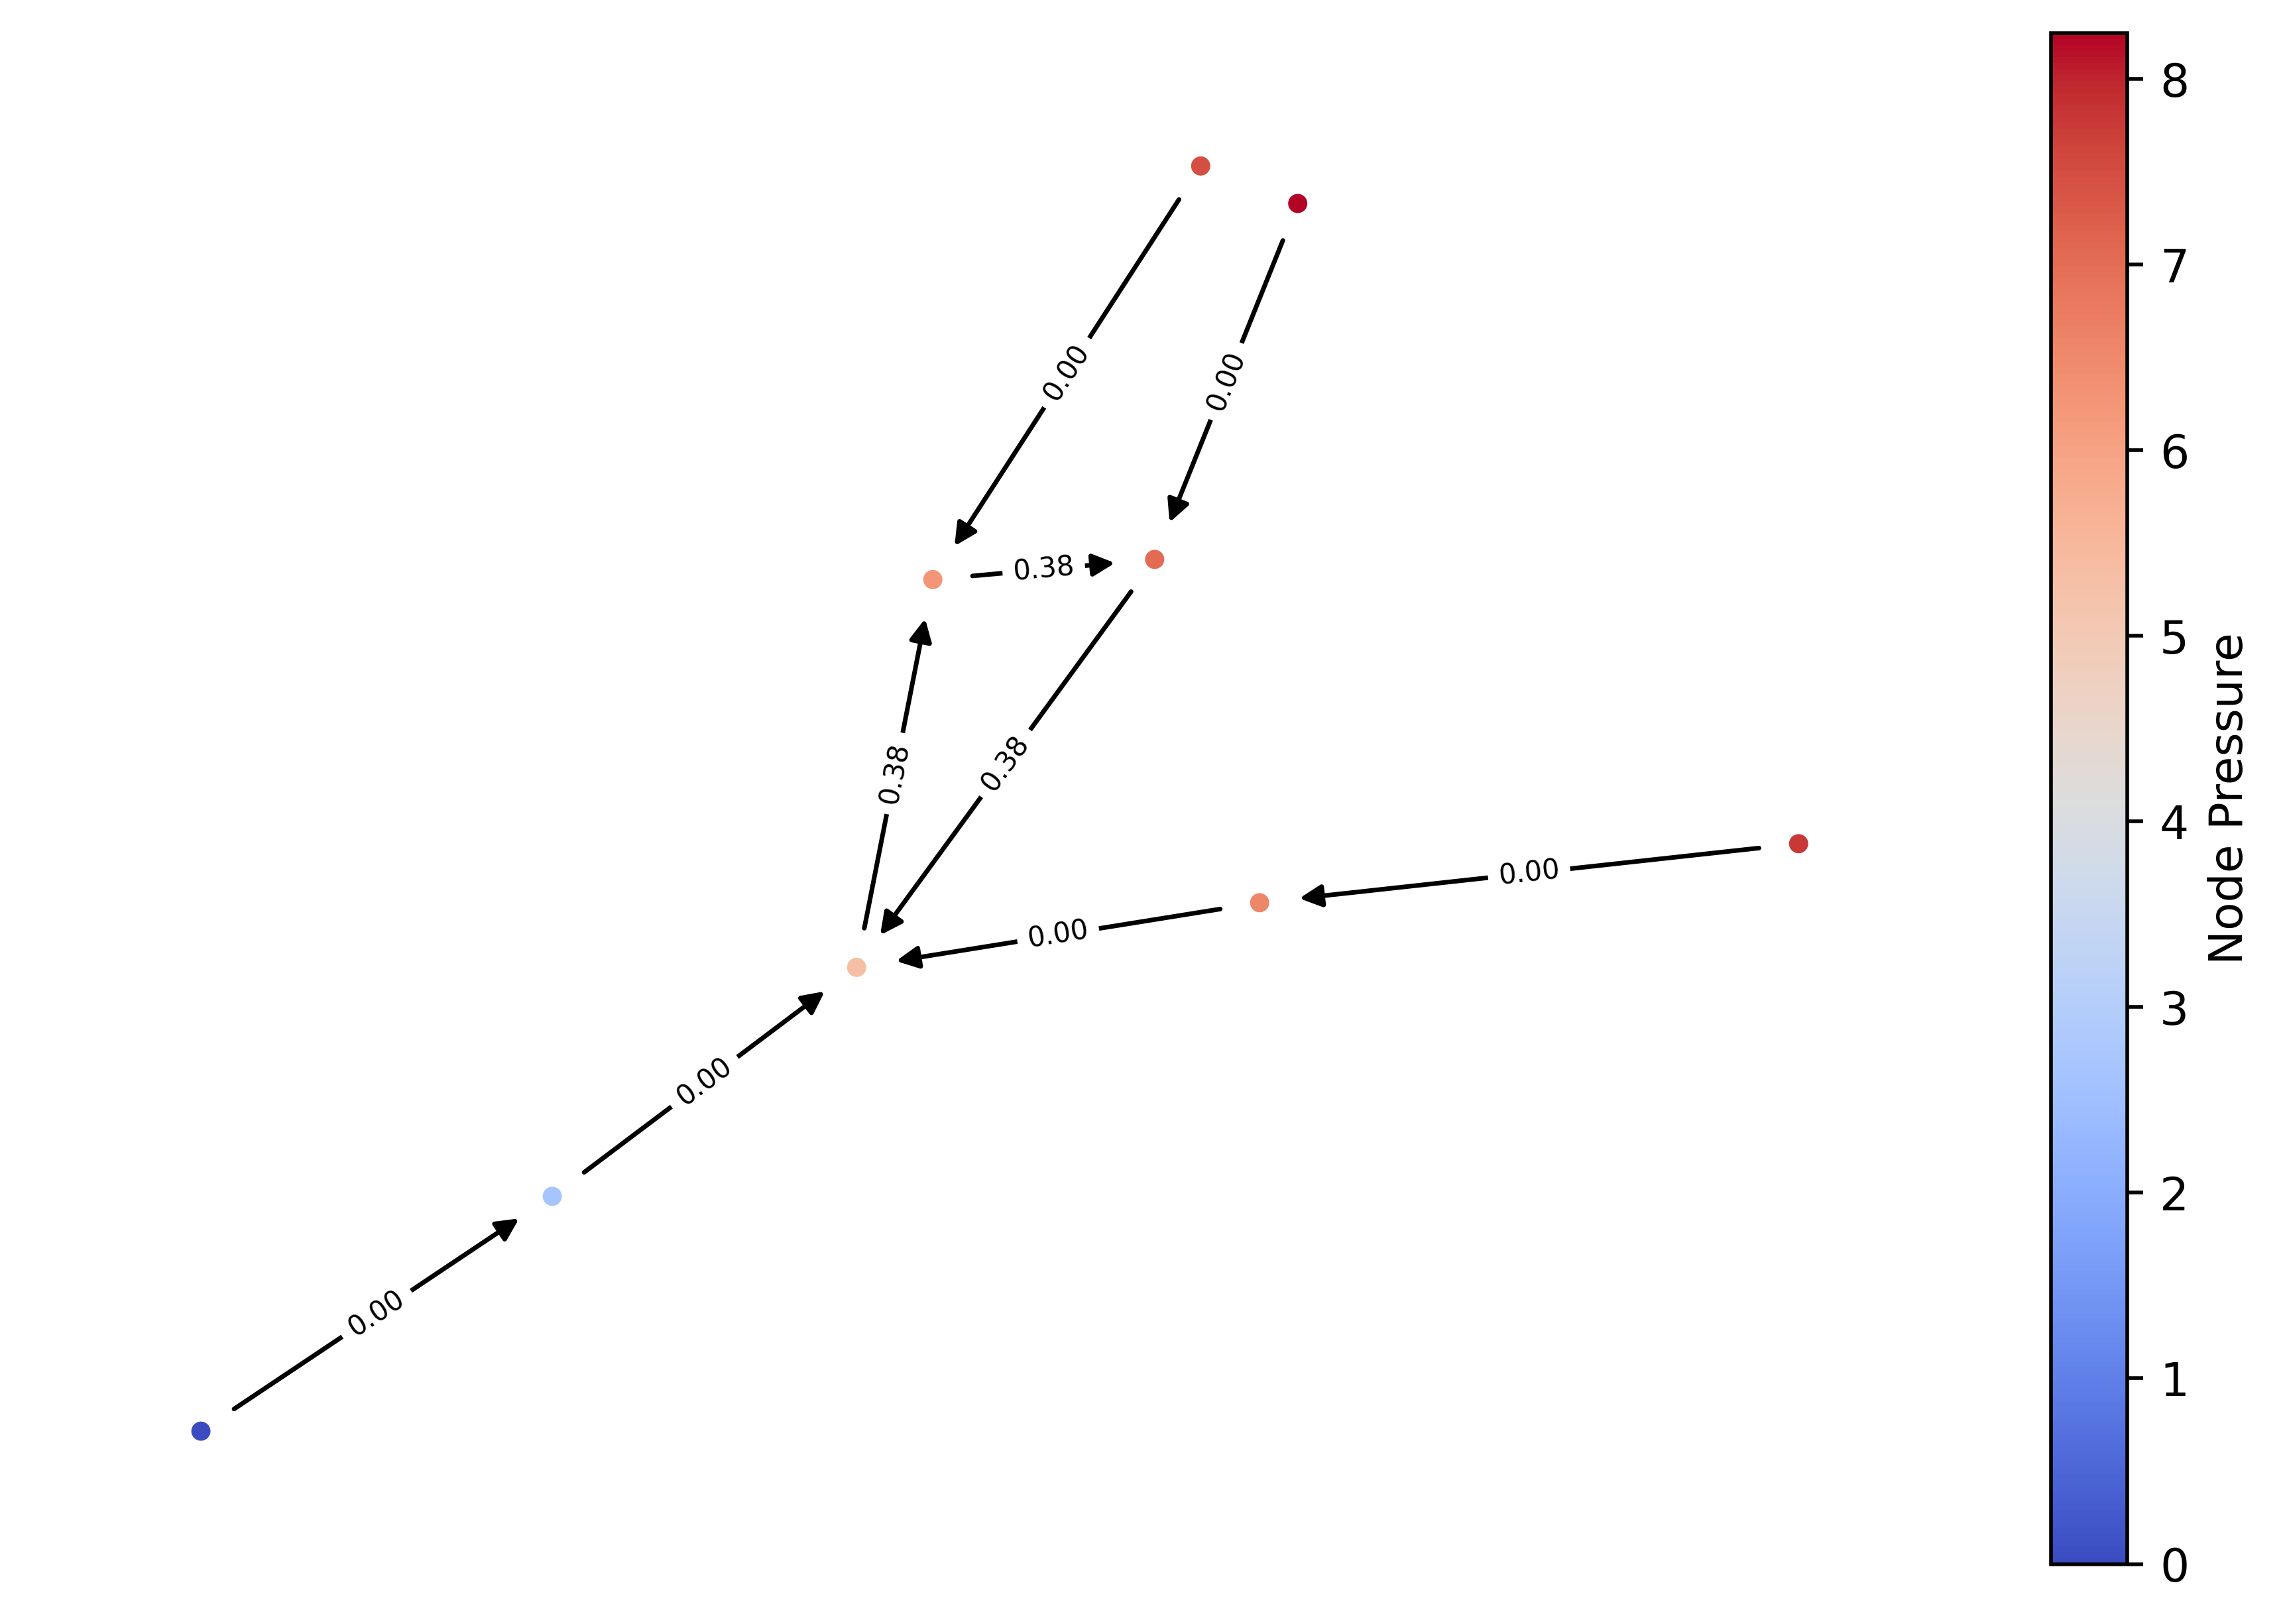

In [24]:


#----- 
# Suppose P_sol and edge_values already computed
node_values = [P_sol[n] for n in G.nodes]  # pressure at each node
edge_values = np.array(Q_w)  # or A, K, or Q (length = num_edges)

# --- NODE COLOR SETUP ---
node_cmap = plt.cm.coolwarm
node_norm = plt.Normalize(vmin=min(node_values), vmax=max(node_values))

# --- EDGE STYLE ---
edge_color = 'black'

fig, ax = plt.subplots(figsize=(7, 5))

# draw nodes w pressure
nx.draw_networkx_nodes(
    G, pos,
    node_color=node_values,
    cmap=node_cmap,
    node_size=10,
    ax=ax
)

# Build flow-directed edges so arrows follow sign(edge_values).
# If value < 0, flip (u,v) -> (v,u).
flow_edges = []
flow_edge_values = []
for (u, v), val in zip(G.edges(), edge_values):
    if val >= 0:
        flow_edges.append((u, v))
        flow_edge_values.append(val)
    else:
        flow_edges.append((v, u))
        flow_edge_values.append(-val)  # flip sign so value matches drawn arrow direction

# draw edges
nx.draw_networkx_edges(
    G, pos,
    edgelist=flow_edges,
    edge_color=edge_color,
    #width=edge_widths,
    arrows=True,
    ax=ax
)

# edge labels
edge_labels = {edge: f"{val:.2f}" for edge, val in zip(flow_edges, flow_edge_values)}
nx.draw_networkx_edge_labels(
    G, pos,
    edge_labels=edge_labels,
    font_color='black',
    font_size=6,
    ax=ax
)

# node colorbar
sm_nodes = plt.cm.ScalarMappable(cmap=node_cmap, norm=node_norm)
sm_nodes.set_array([])
cbar_nodes = fig.colorbar(sm_nodes, ax=ax, fraction=0.046, pad=0.04)
cbar_nodes.set_label('Node Pressure')

plt.axis('off')
plt.rcParams['figure.dpi'] = 500 # For inline display in notebook
plt.tight_layout()
plt.show()

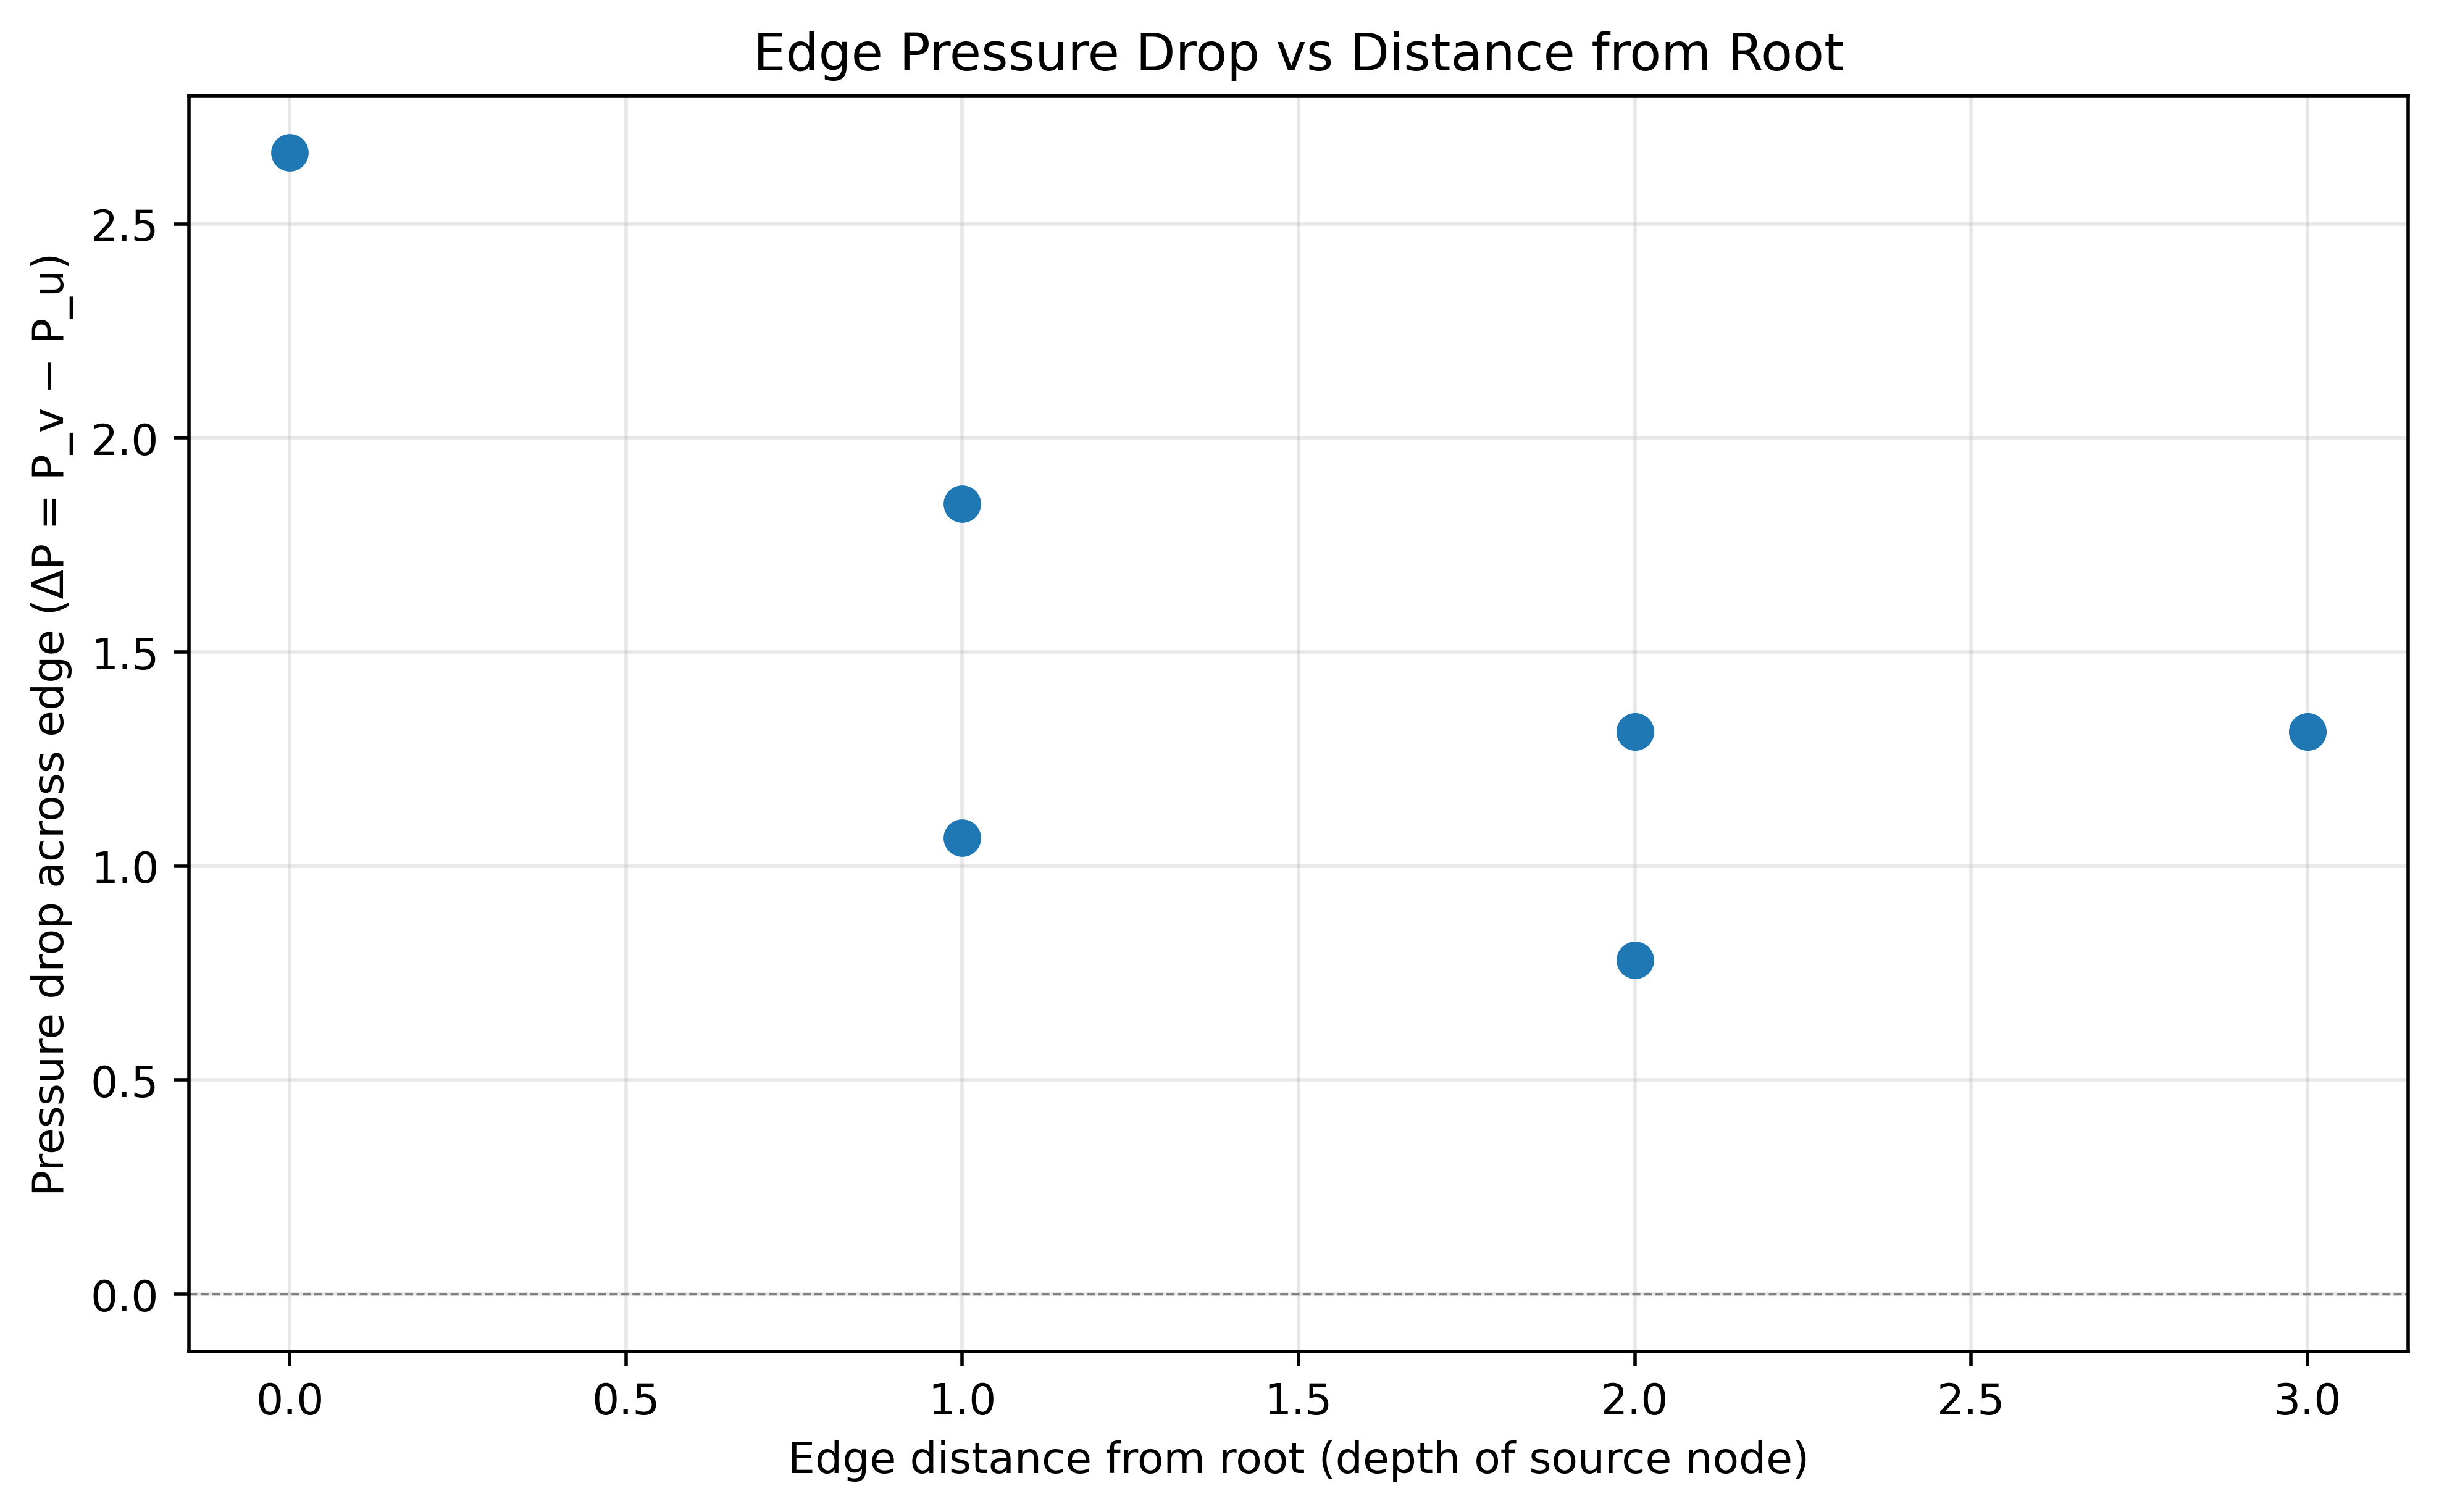

In [251]:
edge_pressures = delta @ P_sol

edge_depth = np.array([nx.shortest_path_length(G, 0, u) for u, v in edges])

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(edge_depth, edge_pressures, s=60, zorder=3)


ax.set_xlabel("Edge distance from root (depth of source node)")
ax.set_ylabel("Pressure drop across edge (ΔP = P_v − P_u)")
ax.set_title("Edge Pressure Drop vs Distance from Root")
ax.axhline(0, color='grey', linewidth=0.5, linestyle='--')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()